# 23 — Dynamic Pricing Optimization (elasticity × forecast 20*)

Tối ưu **BAR / ADR** theo tháng horizon bằng:

- Forecast **Demand · ADR · RevPAR** từ notebooks `20` / `20a` / `20b`  
- Elasticity primary từ notebook `22`  
- Hàm mục tiêu: **maximize revenue proxy** $R(p) = p \cdot Q(p)$ với $Q(p)=Q_0(p/P_0)^\varepsilon$

**Ràng buộc**

- $p \in [0.70\,P_0,\, 1.30\,P_0]$ (band quanh ADR forecast)  
- Soft capacity: $Q(p) \le 1.15\, Q^{\mathrm{fc}}_{\mathrm{demand}}$  
- Floor doanh thu không bắt buộc — báo cáo $\Delta$ vs baseline forecast

**Output:** `optimal_rate_plan.csv` + chart City vs Resort.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "23_optimization"
FIG_DIR.mkdir(parents=True, exist_ok=True)
for slug in ("city", "resort", "compare"):
    (FIG_DIR / slug).mkdir(parents=True, exist_ok=True)

MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
HOTELS = ["City Hotel", "Resort Hotel"]
SLUG = {"City Hotel": "city", "Resort Hotel": "resort"}

print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")

ROOT: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\23_optimization


In [2]:
def savefig(name: str, slug: str | None = None, dpi: int = 120) -> Path:
    folder = FIG_DIR if slug is None else FIG_DIR / slug
    folder.mkdir(parents=True, exist_ok=True)
    path = folder / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def load_stay() -> pd.DataFrame:
    usecols = [
        "hotel", "is_canceled", "adr", "arrival_date_year", "arrival_date_month",
        "Occupancy_Rate", "RevPAR", "revenue", "lead_time", "market_segment",
        "customer_type", "total_of_special_requests", "stays_in_weekend_nights",
        "stays_in_week_nights",
    ]
    df = pd.read_csv(DATA_PATH, usecols=usecols)
    stay = df[(df["is_canceled"] == 0) & (df["adr"] > 0)].copy()
    stay["month"] = stay["arrival_date_month"].map(MONTH_MAP)
    stay["ym"] = pd.to_datetime(
        dict(year=stay["arrival_date_year"], month=stay["month"], day=1)
    )
    stay["los"] = stay["stays_in_weekend_nights"] + stay["stays_in_week_nights"]
    return stay


def monthly_panel(stay: pd.DataFrame) -> pd.DataFrame:
    g = (
        stay.groupby(["hotel", "ym"], as_index=False)
        .agg(
            demand=("adr", "size"),
            adr=("adr", "mean"),
            occ=("Occupancy_Rate", "mean"),
            revpar=("RevPAR", "mean"),
            lead_mean=("lead_time", "mean"),
            lead_p50=("lead_time", "median"),
            los_mean=("los", "mean"),
            special_req=("total_of_special_requests", "mean"),
            share_online_ta=("market_segment", lambda s: (s == "Online TA").mean()),
            share_groups=("market_segment", lambda s: (s == "Groups").mean()),
            share_transient=("customer_type", lambda s: (s == "Transient").mean()),
        )
        .sort_values(["hotel", "ym"])
        .reset_index(drop=True)
    )
    g["month"] = g["ym"].dt.month
    g["log_demand"] = np.log(g["demand"].clip(lower=1))
    g["log_adr"] = np.log(g["adr"].clip(lower=1e-3))
    g["log_revpar"] = np.log(g["revpar"].clip(lower=1e-3))
    return g


def read_forecast_bundle() -> pd.DataFrame:
    """Primary point forecasts + stance from notebooks 20 / 20a / 20b."""
    MODEL_COL = {
        "seasonal_naive": "seasonal_naive",
        "holt_trend": "holt_winters",
        "holt_winters": "holt_winters",
        "holt_winters_seasonal": "holt_winters",
        "sarimax": "sarimax",
    }
    specs = [
        ("demand", "20", "demand_index"),
        ("adr", "20_adr", "metric_index"),
        ("revpar", "20_revpar", "metric_index"),
    ]
    metric_frames = []
    for metric, sub, idx_col in specs:
        hotel_parts = []
        for hotel, slug in SLUG.items():
            fc_path = ROOT / "reports" / "figures" / sub / slug / "forecast_next_6m.csv"
            st_path = ROOT / "reports" / "figures" / sub / slug / "pricing_stance_forecast.csv"
            if not fc_path.exists() or not st_path.exists():
                raise FileNotFoundError(f"Missing forecast artifacts: {fc_path} or {st_path}")
            fc = pd.read_csv(fc_path, parse_dates=["ym"])
            st = pd.read_csv(st_path, parse_dates=["ym"])
            model = str(st["forecast_model"].iloc[0])
            col = MODEL_COL.get(model, model)
            if col not in fc.columns:
                # last resort: pricing stance already stores the primary point forecast
                yhat = st["forecast"]
            else:
                yhat = fc[col]
            tmp = pd.DataFrame({
                "hotel": hotel,
                "ym": st["ym"].values if len(st) == len(yhat) else fc["ym"].values,
                f"fc_{metric}": np.asarray(yhat, dtype=float),
                f"model_{metric}": model,
            })
            st2 = st[["ym", "season_index", idx_col, "combined_pressure", "pricing_stance"]].copy()
            st2 = st2.rename(columns={
                idx_col: f"index_{metric}",
                "season_index": f"season_{metric}",
                "combined_pressure": f"pressure_{metric}",
                "pricing_stance": f"stance_{metric}",
            })
            tmp = tmp.merge(st2, on="ym", how="left")
            hotel_parts.append(tmp)
        metric_frames.append(pd.concat(hotel_parts, ignore_index=True))
    base = metric_frames[0]
    for part in metric_frames[1:]:
        base = base.merge(part, on=["hotel", "ym"], how="outer")
    return base.sort_values(["hotel", "ym"]).reset_index(drop=True)

In [3]:
elas_path = ROOT / "reports" / "figures" / "22_elasticity" / "elasticity_by_hotel.csv"
if not elas_path.exists():
    raise FileNotFoundError(
        "Chạy notebook 22 trước để tạo elasticity_by_hotel.csv\n" + str(elas_path)
    )
elas = pd.read_csv(elas_path)
fc = read_forecast_bundle()
display(elas)
display(fc.head())

,hotel,elasticity_primary,source_method,elasticity_loglog,elasticity_fd,elasticity_segment,note
0,City Hotel,-0.7,rm_prior,3.502343,1.925701,3.317039,OLS biased positive (seasonality/endogeneity) ...
1,Resort Hotel,-1.1,rm_prior,0.405544,0.112803,1.074147,OLS biased positive (seasonality/endogeneity) ...


,hotel,ym,fc_demand,model_demand,season_demand,index_demand,pressure_demand,stance_demand,fc_adr,model_adr,season_adr,index_adr,pressure_adr,stance_adr,fc_revpar,model_revpar,season_revpar,index_revpar,pressure_revpar,stance_revpar
0,City Hotel,2017-09-01,1687.0,seasonal_naive,1.056455,1.246321,1.151388,"PROTECT — raise / harden BAR, limit promo",133.810974,sarimax,1.139104,1.260107,1.199606,PROTECT — harden BAR / limit discounting,88.909766,seasonal_naive,1.226193,1.197477,1.211835,PROTECT — harden BAR / limit discounting
1,City Hotel,2017-10-01,1684.0,seasonal_naive,1.029859,1.244105,1.136982,"NEUTRAL — hold BAR, tactical weekend premium",123.069594,sarimax,1.023677,1.158955,1.091316,"NEUTRAL — hold BAR, tactical weekend premium",78.460403,seasonal_naive,1.077159,1.056740,1.066950,"NEUTRAL — hold BAR, tactical weekend premium"
2,City Hotel,2017-11-01,1469.0,seasonal_naive,0.759096,1.085267,0.922182,"NEUTRAL — hold BAR, tactical weekend premium",108.545763,sarimax,0.821099,1.022183,0.921641,"NEUTRAL — hold BAR, tactical weekend premium",69.872712,seasonal_naive,0.892021,0.941077,0.916549,"NEUTRAL — hold BAR, tactical weekend premium"
3,City Hotel,2017-12-01,1175.0,seasonal_naive,0.710706,0.868066,0.789386,STIMULATE — promo / early-bird / package,106.620948,sarimax,0.877182,1.004057,0.940620,"NEUTRAL — hold BAR, tactical weekend premium",61.258397,seasonal_naive,0.867112,0.825056,0.846084,STIMULATE — promo / early-bird / package
4,City Hotel,2018-01-01,1104.0,seasonal_naive,0.688543,0.815613,0.752078,STIMULATE — promo / early-bird / package,98.203352,sarimax,0.799666,0.924788,0.862227,STIMULATE — promo / early-bird / package,61.630443,seasonal_naive,0.830611,0.830067,0.830339,STIMULATE — promo / early-bird / package


## 1. Local-linear demand + grid search BAR

Iso-elastic thuần với $|\varepsilon|<1$ luôn đẩy giá lên trần band — ít hữu ích cho calendar.

Dùng xấp xỉ tuyến tính quanh $(P_0,Q_0)$:

$$
Q(p)=Q_0\left(1+\varepsilon\frac{p-P_0}{P_0}\right)
$$

rồi chỉnh baseline theo pressure ADR/RevPAR: $P_0' = P_0 \cdot (0.7 + 0.3\cdot \bar{\pi})$.

In [4]:
def optimize_month(
    p0: float,
    q0: float,
    eps: float,
    q_cap: float,
    pressure: float = 1.0,
    lo_mult: float = 0.70,
    hi_mult: float = 1.30,
    n_grid: int = 161,
) -> dict:
    # pressure tilts the reference rate before search
    p_ref = p0 * float(np.clip(0.70 + 0.30 * pressure, 0.80, 1.20))
    prices = np.linspace(p0 * lo_mult, p0 * hi_mult, n_grid)
    # local linear demand from elasticity at (p0, q0)
    demand = q0 * (1.0 + eps * (prices - p0) / p0)
    demand = np.clip(demand, 0.05 * q0, None)
    demand_eff = np.minimum(demand, q_cap)
    revenue = prices * demand_eff
    i = int(np.argmax(revenue))
    # analytical interior (uncapped linear) for reference
    # p_star_analytic = p0 * (eps - 1) / (2 * eps)  for eps < 0
    p_analytic = p0 * (eps - 1.0) / (2.0 * eps) if eps < 0 else p_ref
    return {
        "p_star": float(prices[i]),
        "q_star": float(demand_eff[i]),
        "rev_star": float(revenue[i]),
        "rev_baseline": float(p0 * min(q0, q_cap)),
        "p_ref": float(p_ref),
        "p_analytic": float(p_analytic),
        "grid_prices": prices,
        "grid_revenue": revenue,
    }


opt_rows = []
curve_store = {}

for hotel in HOTELS:
    eps = float(elas.loc[elas["hotel"] == hotel, "elasticity_primary"].iloc[0])
    sub = fc[fc["hotel"] == hotel].copy()
    for _, r in sub.iterrows():
        p0 = float(r["fc_adr"])
        q0 = float(r["fc_demand"])
        q_cap = 1.15 * q0
        pressure = float(np.nanmean([r["pressure_adr"], r["pressure_revpar"], r["pressure_demand"]]))
        out = optimize_month(p0, q0, eps, q_cap, pressure=pressure)
        delta_p = (out["p_star"] / p0 - 1.0) * 100
        delta_rev = (out["rev_star"] / out["rev_baseline"] - 1.0) * 100
        if delta_p >= 3:
            action = "RAISE - harden BAR"
        elif delta_p <= -3:
            action = "CUT - promo / stimulate"
        else:
            action = "HOLD - keep forecast BAR"
        opt_rows.append({
            "hotel": hotel,
            "ym": r["ym"],
            "elasticity": eps,
            "pressure_blend": pressure,
            "p0_adr_fc": p0,
            "q0_demand_fc": q0,
            "revpar_fc": float(r["fc_revpar"]),
            "p_star": out["p_star"],
            "p_analytic": out["p_analytic"],
            "q_star": out["q_star"],
            "rev_star": out["rev_star"],
            "rev_baseline": out["rev_baseline"],
            "delta_price_pct": delta_p,
            "delta_revenue_pct": delta_rev,
            "action": action,
            "stance_demand": r.get("stance_demand"),
            "stance_adr": r.get("stance_adr"),
            "stance_revpar": r.get("stance_revpar"),
            "pressure_demand": r.get("pressure_demand"),
            "pressure_adr": r.get("pressure_adr"),
            "pressure_revpar": r.get("pressure_revpar"),
        })
        curve_store[(hotel, pd.Timestamp(r["ym"]))] = out

opt = pd.DataFrame(opt_rows).sort_values(["hotel", "ym"]).reset_index(drop=True)
display(opt.round(2))
opt.to_csv(FIG_DIR / "optimal_rate_plan.csv", index=False)
print("Saved optimal_rate_plan.csv")

,hotel,ym,elasticity,pressure_blend,p0_adr_fc,q0_demand_fc,revpar_fc,p_star,p_analytic,q_star,...,rev_baseline,delta_price_pct,delta_revenue_pct,action,stance_demand,stance_adr,stance_revpar,pressure_demand,pressure_adr,pressure_revpar
0,City Hotel,2017-09-01,-0.7,1.19,133.81,1687.00,88.91,162.41,162.48,1434.58,...,225739.11,21.38,3.21,RAISE - harden BAR,"PROTECT — raise / harden BAR, limit promo",PROTECT — harden BAR / limit discounting,PROTECT — harden BAR / limit discounting,1.15,1.20,1.21
1,City Hotel,2017-10-01,-0.7,1.10,123.07,1684.00,78.46,149.38,149.44,1432.03,...,207249.20,21.37,3.21,RAISE - harden BAR,"NEUTRAL — hold BAR, tactical weekend premium","NEUTRAL — hold BAR, tactical weekend premium","NEUTRAL — hold BAR, tactical weekend premium",1.14,1.09,1.07
2,City Hotel,2017-11-01,-0.7,0.92,108.55,1469.00,69.87,131.75,131.81,1249.20,...,159453.73,21.38,3.21,RAISE - harden BAR,"NEUTRAL — hold BAR, tactical weekend premium","NEUTRAL — hold BAR, tactical weekend premium","NEUTRAL — hold BAR, tactical weekend premium",0.92,0.92,0.92
3,City Hotel,2017-12-01,-0.7,0.86,106.62,1175.00,61.26,129.41,129.47,999.19,...,125279.61,21.38,3.21,RAISE - harden BAR,STIMULATE — promo / early-bird / package,"NEUTRAL — hold BAR, tactical weekend premium",STIMULATE — promo / early-bird / package,0.79,0.94,0.85
4,City Hotel,2018-01-01,-0.7,0.81,98.20,1104.00,61.63,119.19,119.25,938.81,...,108416.50,21.38,3.21,RAISE - harden BAR,STIMULATE — promo / early-bird / package,STIMULATE — promo / early-bird / package,STIMULATE — promo / early-bird / package,0.75,0.86,0.83
5,City Hotel,2018-02-01,-0.7,0.91,100.51,1298.00,65.82,121.99,122.05,1103.79,...,130459.70,21.38,3.21,RAISE - harden BAR,"NEUTRAL — hold BAR, tactical weekend premium",STIMULATE — promo / early-bird / package,STIMULATE — promo / early-bird / package,0.95,0.90,0.89
6,Resort Hotel,2017-09-01,-1.1,1.14,117.22,942.41,82.03,111.95,111.90,989.06,...,110472.73,-4.50,0.23,CUT - promo / stimulate,"NEUTRAL — hold BAR, tactical weekend premium",PROTECT — harden BAR / limit discounting,PROTECT — harden BAR / limit discounting,0.97,1.24,1.21
7,Resort Hotel,2017-10-01,-1.1,0.89,70.37,1077.36,53.07,67.20,67.17,1130.68,...,75810.47,-4.50,0.23,CUT - promo / stimulate,"NEUTRAL — hold BAR, tactical weekend premium",STIMULATE — promo / early-bird / package,STIMULATE — promo / early-bird / package,1.12,0.77,0.80
8,Resort Hotel,2017-11-01,-1.1,0.72,52.53,884.83,44.08,50.17,50.14,928.63,...,46481.58,-4.50,0.23,CUT - promo / stimulate,"NEUTRAL — hold BAR, tactical weekend premium",STIMULATE — promo / early-bird / package,STIMULATE — promo / early-bird / package,0.91,0.59,0.66
9,Resort Hotel,2017-12-01,-1.1,0.84,71.41,877.36,55.40,68.20,68.16,920.79,...,62651.08,-4.50,0.23,CUT - promo / stimulate,"NEUTRAL — hold BAR, tactical weekend premium",STIMULATE — promo / early-bird / package,STIMULATE — promo / early-bird / package,0.90,0.78,0.83


Saved optimal_rate_plan.csv


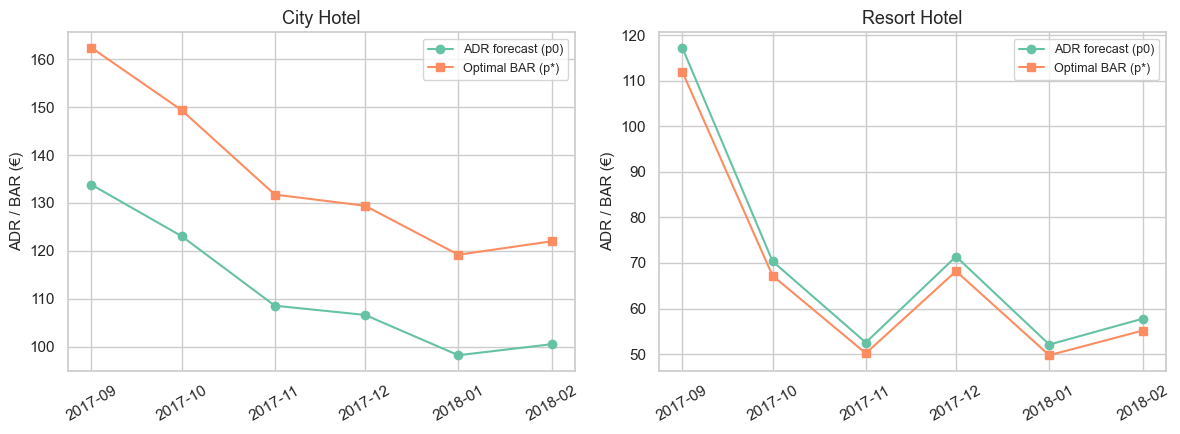

Saved: reports\figures\23_optimization\compare\01_p0_vs_pstar.png


WindowsPath('c:/Users/ADMIN/OneDrive/Tài liệu/oneDrive/Desktop/DA/Project/Hotel Booking Demand/Python/reports/figures/23_optimization/compare/01_p0_vs_pstar.png')

In [5]:
# Overlay p0 vs p* for each hotel
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, hotel in zip(axes, HOTELS):
    sub = opt[opt["hotel"] == hotel]
    ax.plot(sub["ym"], sub["p0_adr_fc"], marker="o", label="ADR forecast (p0)")
    ax.plot(sub["ym"], sub["p_star"], marker="s", label="Optimal BAR (p*)")
    ax.set_title(hotel)
    ax.set_ylabel("ADR / BAR (€)")
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", rotation=30)
savefig("01_p0_vs_pstar.png", slug="compare")

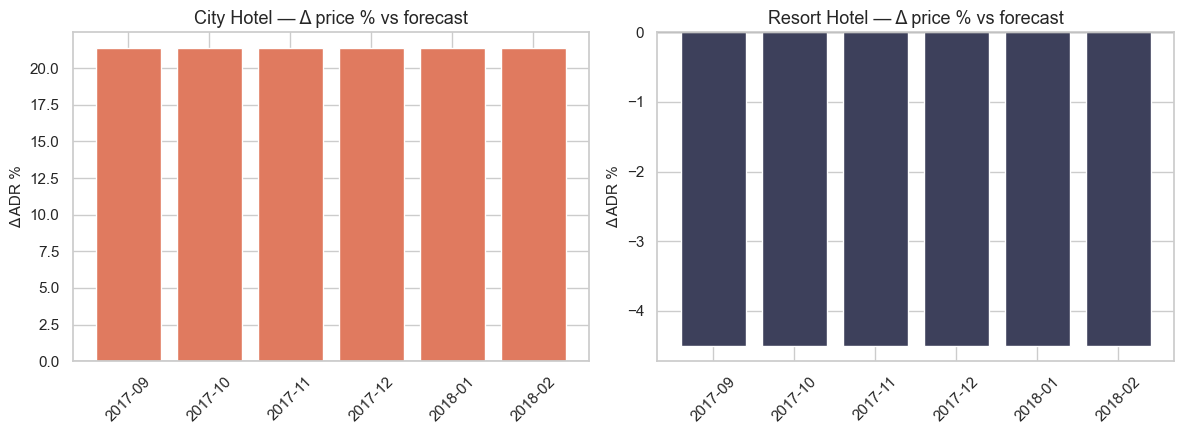

Saved: reports\figures\23_optimization\compare\02_delta_price_pct.png


WindowsPath('c:/Users/ADMIN/OneDrive/Tài liệu/oneDrive/Desktop/DA/Project/Hotel Booking Demand/Python/reports/figures/23_optimization/compare/02_delta_price_pct.png')

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, hotel in zip(axes, HOTELS):
    sub = opt[opt["hotel"] == hotel]
    colors = sub["action"].map({
        "RAISE - harden BAR": "#e07a5f",
        "HOLD - keep forecast BAR": "#81b29a",
        "CUT - promo / stimulate": "#3d405b",
    })
    ax.bar(sub["ym"].dt.strftime("%Y-%m"), sub["delta_price_pct"], color=colors)
    ax.axhline(0, color="gray", lw=1)
    ax.set_title(f"{hotel} — Δ price % vs forecast")
    ax.set_ylabel("Δ ADR %")
    ax.tick_params(axis="x", rotation=45)
savefig("02_delta_price_pct.png", slug="compare")

## 2. Revenue curve mẫu (tháng lệch pha Oct)

Vẽ $R(p)$ cho **2017-10** — tháng Resort STIMULATE trong report 21.

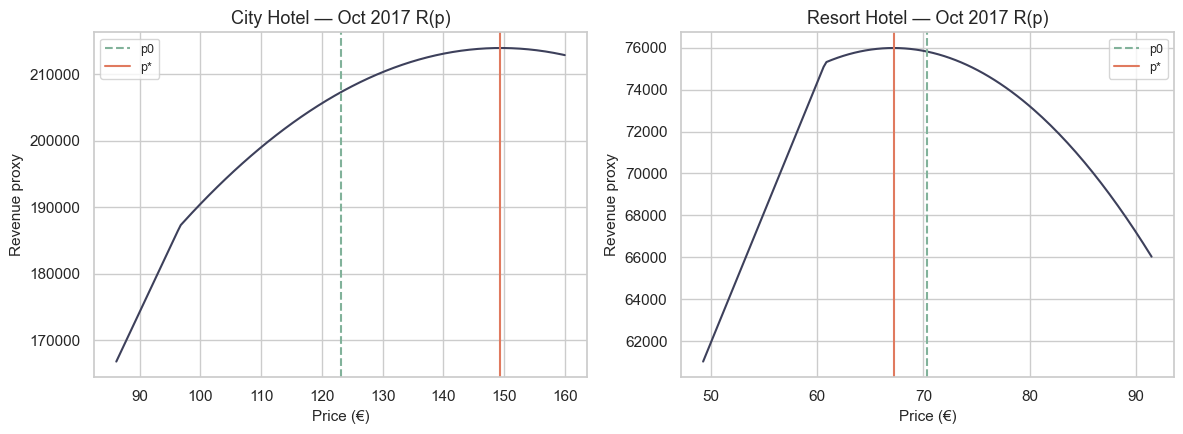

Saved: reports\figures\23_optimization\compare\03_revenue_curve_oct2017.png


WindowsPath('c:/Users/ADMIN/OneDrive/Tài liệu/oneDrive/Desktop/DA/Project/Hotel Booking Demand/Python/reports/figures/23_optimization/compare/03_revenue_curve_oct2017.png')

In [7]:
target_ym = pd.Timestamp("2017-10-01")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, hotel in zip(axes, HOTELS):
    key = (hotel, target_ym)
    if key not in curve_store:
        ax.set_title(f"{hotel} — missing {target_ym.date()}")
        continue
    out = curve_store[key]
    row = opt[(opt["hotel"] == hotel) & (opt["ym"] == target_ym)].iloc[0]
    ax.plot(out["grid_prices"], out["grid_revenue"], color="#3d405b")
    ax.axvline(row["p0_adr_fc"], color="#81b29a", ls="--", label="p0")
    ax.axvline(row["p_star"], color="#e07a5f", ls="-", label="p*")
    ax.set_title(f"{hotel} — Oct 2017 R(p)")
    ax.set_xlabel("Price (€)")
    ax.set_ylabel("Revenue proxy")
    ax.legend(fontsize=9)
savefig("03_revenue_curve_oct2017.png", slug="compare")

## 3. Đối chiếu stance forecast vs action tối ưu

| | |
|---|---|
| Stance 20* | Tín hiệu hướng (PROTECT / NEUTRAL / STIMULATE) |
| Action 23 | Biên độ % BAR cụ thể từ elasticity |

Nếu mâu thuẫn (ví dụ STIMULATE nhưng tối ưu RAISE) → ưu tiên **floor ADR** + kiểm tra Occ proxy / capacity thật.

In [8]:
def stance_bucket(s: str) -> str:
    s = str(s)
    if s.startswith("PROTECT"):
        return "PROTECT"
    if s.startswith("STIMULATE"):
        return "STIMULATE"
    return "NEUTRAL"


cmp = opt.copy()
for col in ["stance_demand", "stance_adr", "stance_revpar"]:
    cmp[col + "_b"] = cmp[col].map(stance_bucket)
cmp["action_b"] = cmp["action"].map(
    lambda a: "RAISE" if a.startswith("RAISE") else ("CUT" if a.startswith("CUT") else "HOLD")
)

summary = (
    cmp.groupby(["hotel", "action_b"])
    .agg(
        n=("ym", "count"),
        mean_delta_p=("delta_price_pct", "mean"),
        mean_delta_rev=("delta_revenue_pct", "mean"),
    )
    .reset_index()
)
display(summary.round(2))
summary.to_csv(FIG_DIR / "action_summary.csv", index=False)

# City vs Resort plan side-by-side
pivot = opt.pivot_table(
    index="ym",
    columns="hotel",
    values=["p0_adr_fc", "p_star", "delta_price_pct", "action"],
    aggfunc="first",
)
display(pivot)
pivot.to_csv(FIG_DIR / "compare" / "city_vs_resort_rate_plan.csv")

,hotel,action_b,n,mean_delta_p,mean_delta_rev
0,City Hotel,RAISE,6,21.38,3.21
1,Resort Hotel,CUT,6,-4.50,0.23


action                          delta_price_pct  \
hotel               City Hotel             Resort Hotel      City Hotel   
ym                                                                        
2017-09-01  RAISE - harden BAR  CUT - promo / stimulate          21.375   
2017-10-01  RAISE - harden BAR  CUT - promo / stimulate          21.375   
2017-11-01  RAISE - harden BAR  CUT - promo / stimulate          21.375   
2017-12-01  RAISE - harden BAR  CUT - promo / stimulate          21.375   
2018-01-01  RAISE - harden BAR  CUT - promo / stimulate          21.375   
2018-02-01  RAISE - harden BAR  CUT - promo / stimulate          21.375   

                          p0_adr_fc                   p_star               
hotel      Resort Hotel  City Hotel Resort Hotel  City Hotel Resort Hotel  
ym                                                                         
2017-09-01         -4.5  133.810974   117.223703  162.413070   111.948636  
2017-10-01         -4.5  123.069594    70.367188  149.375720    67.200665  
2017-11-01         -4.5  108.545763    52.531588  131.747419    50.167666  
2017-12-01         -4.5  106.620948    71.408660  129.411176    68.195270  
2018-01-01         -4.5   98.203352    52.094021  119.194318    49.749790  
2018-02-01         -4.5  100.508247    57.751826  121.991885    55.152994

## 4. Hạn chế

1. $Q(p)=Q_0(p/P_0)^\varepsilon$ — iso-elastic đơn giản, không competitive set.  
2. Capacity = 1.15× demand forecast (proxy), không phải rooms available.  
3. Horizon 2018 minh họa (dataset cắt 2017-08).  
4. Recommend-only — validate pickup trước khi lock BAR.